# Trabalho Final - Redes Neurais

  **Dataset Escolhido:** [Crossfit Games](https://www.kaggle.com/datasets/tgomesjuliana/crossfit-games/data)





**Objetivo da análise:**

  No CrossFit, seja nos treinos diários ou em grandes competições como o Open e os Games, existem diferenças naturais de biotipo entre os competidores. O objetivo principal deste trabalho é aplicar Redes Neurais para analisar esses dados demográficos e físicos, testando a capacidade de aprendizado do modelo de classificação.

  Especificamente, nosso modelo foi construído e treinado para prever o gênero (Feminino ou Masculino) de um atleta baseando-se unicamente em duas variáveis de entrada: a idade e a altura. A ideia central é avaliar se a rede neural consegue identificar padrões e discrepâncias físicas apenas com essas duas métricas a ponto de realizar uma classificação precisa, antes mesmo de analisarmos qualquer dado de performance ou carga levantada.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [17]:
df = pd.read_csv('df_games_and_open.csv')

df_clean = df[['age', 'height', 'gender']].dropna()

df_clean = df_clean[(df_clean['height'] > 140) & (df_clean['height'] < 220)]


df_clean['gender'] = df_clean['gender'].map({'F': 0, 'M': 1})

X = df_clean[['age', 'height']]
y = df_clean['gender']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Tamanho do treino: {X_train_scaled.shape[0]} amostras")
print(f"Tamanho do teste: {X_test_scaled.shape[0]} amostras")

Tamanho do treino: 1371 amostras
Tamanho do teste: 343 amostras


In [10]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
history = model.fit(X_train_scaled, y_train,
                    epochs=30,
                    batch_size=32,
                    validation_split=0.2
                   )

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6122 - loss: 0.7021 - val_accuracy: 0.7418 - val_loss: 0.6590
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7655 - loss: 0.6355 - val_accuracy: 0.7709 - val_loss: 0.5931
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8093 - loss: 0.5670 - val_accuracy: 0.8036 - val_loss: 0.5264
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8422 - loss: 0.4974 - val_accuracy: 0.8145 - val_loss: 0.4632
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8568 - loss: 0.4361 - val_accuracy: 0.8327 - val_loss: 0.4149
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8622 - loss: 0.3910 - val_accuracy: 0.8218 - val_loss: 0.3858
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8714 - loss: 0.3634 - val_accuracy: 0.8255 - val_loss: 0.3711
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8714 - loss: 0.3495 - val_accuracy: 0.8255 - val

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8513 - loss: 0.3254 

Acurácia no Teste: 85.13%
Perda (Loss) no Teste: 0.3254



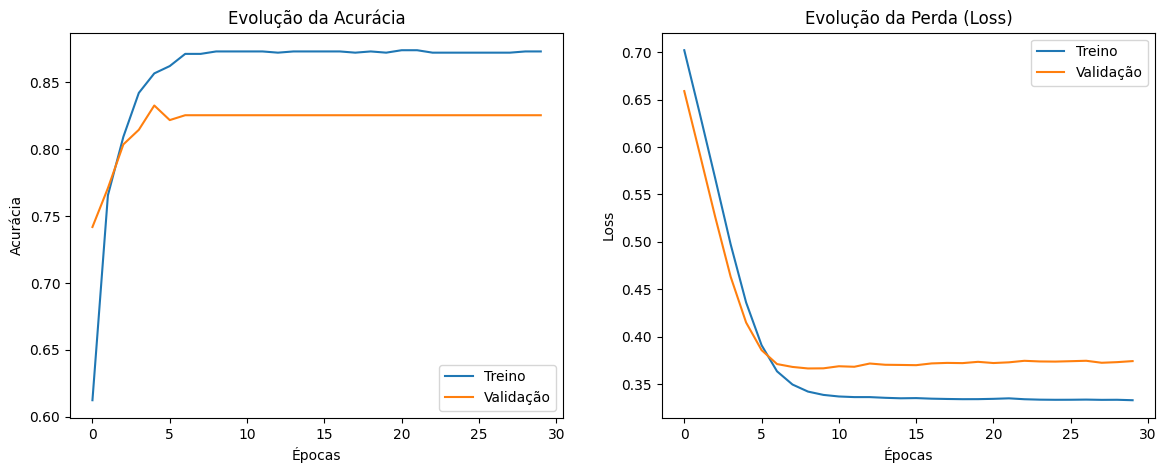

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

Matriz de Confusão:
[[141  15]
 [ 36 151]]

Relatório de Classificação:
              precision    recall  f1-score   support

    Feminino       0.80      0.90      0.85       156
   Masculino       0.91      0.81      0.86       187

    accuracy                           0.85       343
   macro avg       0.85      0.86      0.85       343
weighted avg       0.86      0.85      0.85       343



In [12]:
# Avaliando o modelo nos dados de teste
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"\nAcurácia no Teste: {accuracy * 100:.2f}%")
print(f"Perda (Loss) no Teste: {loss:.4f}\n")

# Plotando gráficos de Acurácia e Perda
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Acurácia
ax[0].plot(history.history['accuracy'], label='Treino')
ax[0].plot(history.history['val_accuracy'], label='Validação')
ax[0].set_title('Evolução da Acurácia')
ax[0].set_xlabel('Épocas')
ax[0].set_ylabel('Acurácia')
ax[0].legend()

# Gráfico de Loss (Perda)
ax[1].plot(history.history['loss'], label='Treino')
ax[1].plot(history.history['val_loss'], label='Validação')
ax[1].set_title('Evolução da Perda (Loss)')
ax[1].set_xlabel('Épocas')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.show()

# Matriz de Confusão
y_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Feminino', 'Masculino']))

### Relatório de Experiência e Conclusões

Analisando os gráficos de desempenho que a gente gerou, deu pra ver que a rede aprendeu bem rápido. Lá pela época 10, ela já tinha estabilizado. A acurácia de validação ficou ali na casa dos 82%, enquanto a de treino foi bater perto dos 88%. Olhando pro gráfico de loss (perda), deu pra notar que rolou um leve overfitting depois da época 10. A perda da validação meio que estacionou num platô, mas a do treino continuou caindo. Ou seja, a partir dali, o modelo começou a 'decorar' os dados de treino em vez de aprender de verdade.

No fim das contas, achamos o resultado super positivo. Como a curva de validação
não começou a subir do nada de novo, quer dizer que o modelo conseguiu generalizar bem e que essa estrutura de rede que escolhemos funcionou.
